### Experiment: Effect of Prediction Head Capacity

In this experiment we study how the capacity of the prediction head affects performance when the temporal context is limited.

We use the same **nonlinear sequence simulation** described earlier. The sequence contains community-structured transitions where the traversal direction depends on the **parity of the sum of the previous \(K\) community visits**, introducing a long-range dependency.

The recurrent backbone is trained with a **fixed BPTT length of 3**, which is intentionally shorter than the dependency length. As a result, the recurrent layer alone cannot fully capture the required temporal structure.

To investigate whether downstream model capacity can compensate for this limitation, we gradually increase the **number of neurons in the prediction head** (MLP head) while keeping all other components fixed.

#### Experimental Setup

- Dataset: nonlinear community traversal sequence  
- Recurrent backbone: RNN  
- BPTT length: **4**  
- Training regime: single-pass online learning  
- Prediction head: MLP with varying number of layers  

#### Variable

We vary the **number of neurons in the prediction head**:


In [2]:
## Load necessary library files ##

import sys
sys.path.append('..')
from sharp.utils import get_sequence, DatasetConverter
from sharp.model.model import Model

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch import from_numpy as tnsr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm
import pickle 

In [2]:
## select device ##
device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


In [3]:
## load the nonlinear simulation from source files ##
print("A 42 tokens long nonlinear sequence ", get_sequence(42, n_community=2, n_members=3, context_depth=4, train_percent=1.0))

A 42 tokens long nonlinear sequence  CABGDEFGDEFGABCGFDEGEDFGFEDGFEDGDEFGEFDGEF


In [4]:
total_samples, n_community, n_members, context_depth = 1000000, 2, 3, 4
total_layers, short_term_memory = 2, 4

vocab_size = n_community*n_members + 1


In [5]:
reps = 10
head_layers = [1, 2, 3, 4, 5]
res = []
repititions = []
head_size = []
samples_seen = []

for rep in tqdm(range(reps)):
    for head_layer in head_layers:
        model = Model(
            total_layers = total_layers,
            num_layers_prediction_head = head_layer,

            # ---- Layer sizes ----
            vocab_size = vocab_size,                  # layer 0 input dimension
            hidden_sizes = [100, 100],    # H0, H1
            embedding_dim = 30,

            # ---- Learning rates per layer ----
            lr_layers = 1e-4,   

            # ---- Optimizer type (user can choose) ----
            optimizer_class = torch.optim.Adam,
            optimizer_kwargs = {
                "weight_decay": 1e-12
            },

            # ---- Sleep hyperparameters ----
            short_term_memory = short_term_memory,
            context_tag_buffer_size=100,
            # ---- Misc ----
            recon_threshold = 1e-3,
            device = device
        )

        data = get_sequence(total_samples, n_community, n_members, context_depth=context_depth, train_percent=1.0)
        dataset = DatasetConverter(data, short_term_memory=short_term_memory)
        loader = DataLoader(dataset, batch_size=1, shuffle=False)
        
        ii = 0 
        h_ = None
        correct_ring = np.zeros(1000)
        for x, y in loader:
            x = x.to(device).long()
            y = y.to(device).long()
            logits, loss, recon_loss, h_ = model.wake_step(x, y, h_)


            with torch.no_grad():
                ii += 1
                pred_tok = logits.argmax(dim=-1)
                correct_ring[ii % 1000] = (pred_tok[0] == y[0, 0]).item()
                
                if ii%1000 == 0:
                    acc = np.sum(correct_ring) / (1000 if ii >= 1000 else ii)
                    res.append(acc)
                    samples_seen.append(ii)
                    repititions.append(rep)
                    head_size.append(head_layer)


            if ii%20000==0:
                model.sleep(total_steps=16)


df = pd.DataFrame()
df['reps'] = repititions
df['samples seen'] = samples_seen
df['head size'] = head_size
df['Accuracy'] = res

with open('../pickle_files/head_complexity.pickle', 'wb') as f:
    pickle.dump(df, f)

100%|██████████| 10/10 [21:39:16<00:00, 7795.62s/it]  


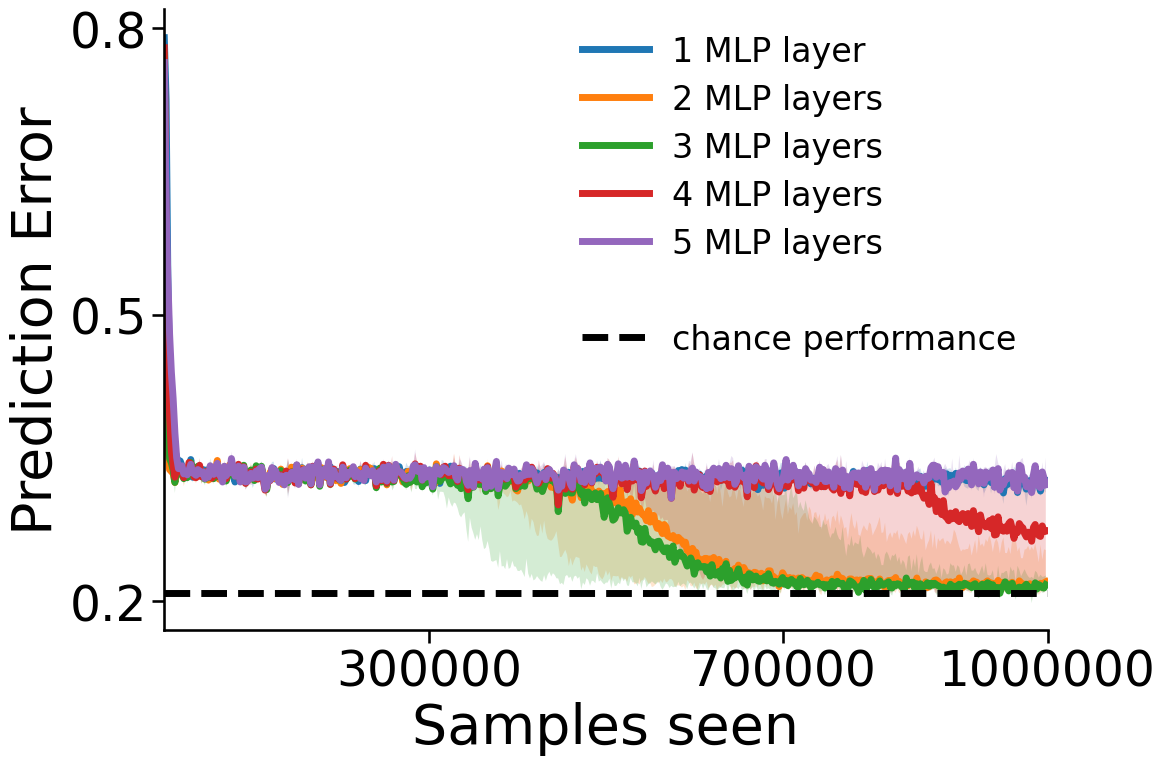

Saved figure to: ../plots/head_capacity.pdf


In [9]:
sns.set_context("talk")

# --------- Load ----------
with open('../pickle_files/head_complexity.pickle', 'rb') as f:
    df = pickle.load(f)

df = df.copy()
df["samples_seen"] = df["samples seen"]
df["head_size"] = df["head size"]

# --------- Convert to ERROR ----------
df["Error"] = 1.0 - df["Accuracy"]

# --------- Downsample to reduce noise ----------
BIN = 2000
df["bin"] = (df["samples_seen"] // BIN).astype(int)
df["x_bin"] = df["bin"] * BIN

# --------- Aggregate across reps: median + IQR in each bin ----------
def stats_by_head(df_head):
    g = df_head.groupby("x_bin")["Error"]

    x = g.median().index.values
    med = g.median().values
    q25 = g.quantile(0.25).values
    q75 = g.quantile(0.75).values

    return x, med, q25, q75

# --------- Plot ----------
fig, ax = plt.subplots(figsize=(12, 8))

head_layers = sorted(df["head_size"].unique())

line_handles = []
line_labels = []

for head in head_layers:
    sub = df[df["head_size"] == head]
    x, med, q25, q75 = stats_by_head(sub)

    line, = ax.plot(
        x,
        med,
        linewidth=5,
        label=f"{head} MLP layer" if head == 1 else f"{head} MLP layers"
    )

    ax.fill_between(
        x,
        q25,
        q75,
        alpha=0.20
    )

    line_handles.append(line)
    line_labels.append(f"{head} MLP layer" if head == 1 else f"{head} MLP layers")

# --------- Chance / optimal line ----------
chance_acc = 0.7917
chance_err = 1.0 - chance_acc

chance_handle = ax.axhline(
    chance_err,
    linestyle="--",
    color="black",
    linewidth=5
)

# --------- Axis formatting ----------
ax.tick_params(labelsize=35)

ax.set_yticks([0.2, 0.5, 0.8])
ax.set_xticks([300000, 700000, 1000000])

ax.set_xlim([0, 1000000])
ax.set_ylim([0.17, 0.82])

ax.set_xlabel("Samples seen", fontsize=40)
ax.set_ylabel("Prediction Error", fontsize=40)

ax.ticklabel_format(style="plain", axis="x")

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# --------- Legend inside top-right blank space ----------
spacer_handle = plt.Line2D(
    [0],
    [0],
    color="none",
    linewidth=0
)

handles = line_handles + [spacer_handle, chance_handle]
labels = line_labels + ["", "chance performance"]

ax.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    frameon=False,
    fontsize=24,
    handlelength=2.0,
    handletextpad=0.7,
    labelspacing=0.45,
    borderaxespad=0.0
)

# --------- Layout ----------
plt.tight_layout()

# --------- Save ----------
os.makedirs("../plots", exist_ok=True)

outpath = "../plots/head_capacity.pdf"

fig.savefig(outpath, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {outpath}")